# 5. Stunde: Erstes Neuronales Netzwerk trainieren
## Mehrschichtiges Fully Connected Network

In diesem Notebook trainieren wir unser erstes echtes neuronales Netzwerk zur Handschrifterkennung.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
try:
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    print("Cannot import tensorflow: using jax")
    os.environ["KERAS_BACKEND"] = "jax"
    import keras
    from keras import layers
import time

print("✓ Alle Bibliotheken importiert")

Cannot import tensorflow: using jax
✓ Alle Bibliotheken importiert


## 1. Daten laden und vorbereiten

In [2]:
# MNIST-Daten laden
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Rohdaten geladen:")
print(f"  Training: {x_train.shape}, Labels: {y_train.shape}")
print(f"  Test: {x_test.shape}, Labels: {y_test.shape}")

# Daten vorbereiten: Reshape und Normalisieren
x_train_flat = x_train.reshape(-1, 784) / 255.0
x_test_flat = x_test.reshape(-1, 784) / 255.0

# One-Hot Encoding der Labels
y_train_encoded = keras.utils.to_categorical(y_train, 10)
y_test_encoded = keras.utils.to_categorical(y_test, 10)

print("\nDaten vorbereitet:")
print(f"  Training Bilder: {x_train_flat.shape}")
print(f"  Training Labels (One-Hot): {y_train_encoded.shape}")
print(f"  Pixel-Bereich: [{x_train_flat.min():.2f}, {x_train_flat.max():.2f}]")

Rohdaten geladen:
  Training: (60000, 28, 28), Labels: (60000,)
  Test: (10000, 28, 28), Labels: (10000,)

Daten vorbereitet:
  Training Bilder: (60000, 784)
  Training Labels (One-Hot): (60000, 10)
  Pixel-Bereich: [0.00, 1.00]


## 2. Modell-Architektur definieren

In [3]:
def build_model(
    input_size=784,
    hidden_layers=[128, 64],
    activation="relu",
    dropout_rate=0.0,
    output_classes=10,
    output_activation="softmax",
    learning_rate=0.001
):
    """
    Erstellt ein vollständig verbundenes neuronales Netzwerk.

    Parameters
    ----------
    input_size:
        Anzahl Eingabewerte (MNIST: 784 Pixel)

    hidden_layers:
        Liste mit Anzahl Neuronen pro versteckter Schicht

    activation:
        Aktivierungsfunktion der versteckten Schichten

    dropout_rate:
        Anteil der ausgeschalteten Neuronen während Training

    output_classes:
        Anzahl Klassen

    learning_rate:
        Schrittweite beim Lernen
    """


    model = keras.Sequential()


    # Input + Hidden Layers

    for i, neurons in enumerate(hidden_layers):

        if i == 0:
            model.add( layers.Dense( neurons, activation=activation, input_shape=(input_size,), name=f"hidden_layer_{i+1}"))
        else:
            model.add( layers.Dense( neurons, activation=activation, name=f"hidden_layer_{i+1}"))

        if dropout_rate > 0:
            model.add( layers.Dropout( dropout_rate, name=f"dropout_{i+1}"))

    # Output layer
    model.add( layers.Dense( output_classes, activation=output_activation, name="output_layer"))
    optimizer = keras.optimizers.Adam( learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        # loss="sparse_categorical_crossentropy",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )


    return model

### Different Models

In [4]:
model_linear = build_model(
    hidden_layers=[],
    activation=None
)

model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ output_layer (Dense)                 │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
model_medium = build_model(
    hidden_layers=[
        128,
        64
    ],
    activation="relu",
    dropout_rate=0.1
)

model_medium.summary()

C:\Users\localdmin\Documents\stefano\project\gitHub\Handschrifterkennung\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)               │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_2 (Dense)               │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_deep = build_model(
    hidden_layers=[
        512,
        256,
        128
    ],
    activation="relu",
    dropout_rate=0.2
)

model_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)               │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_2 (Dense)               │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_3 (Dense)               │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Modell erstellen: 784 → 512 → 256 → 128 → 10 (verbesserte Architektur)
# model = keras.Sequential([
#     layers.Dense(512, activation='relu', input_shape=(784,), name='input_layer_0'),
#     layers.Dropout(0.2, name='dropout_1'),
#     layers.Dense(256, activation='relu', name='hidden_layer_1'),
#     layers.Dropout(0.2, name='dropout_2'),
#     layers.Dense(128, activation='relu', name='hidden_layer_2'),
#     layers.Dropout(0.2, name='dropout_3'),
#     layers.Dense(10, activation='softmax', name='output_layer')
# ])

# # Modell Zusammenfassung
# model.summary()
# 
# Parameter zählen
# total_params = model.count_params()
# print(f"\nGesamte Parameter: {total_params:,}")

## 3. Modell kompilieren

In [8]:
# Optimierer mit Learning Rate
# optimizer = keras.optimizers.Adam(learning_rate=0.001)

# Modell kompilieren
# model.compile(
    # optimizer=optimizer,
    # loss='categorical_crossentropy',
    # metrics=['accuracy']
# )

# print("✓ Modell kompiliert mit:")
# print("  - Optimizer: Adam (Learning Rate = 0.001)")
# print("  - Loss: Categorical Crossentropy")
# print("  - Metriken: Accuracy")

In [9]:
model = model_deep

## 4. Modell trainieren

In [10]:
# Training mit Validierungsdaten
print("Training startet...\n")
start_time = time.time()

history = model.fit(
    x_train_flat, y_train_encoded,
    epochs=15,
    batch_size=32,
    verbose=1
)

training_time = time.time() - start_time
print(f"\n✓ Training beendet in {training_time:.2f} Sekunden")

Training startet...

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9209 - loss: 0.2570
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9635 - loss: 0.1237
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9723 - loss: 0.0943
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9756 - loss: 0.0807
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9791 - loss: 0.0690
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0632
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9841 - loss: 0.0557
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0511
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0493
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9872 - loss: 0.0429
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9878 - loss: 0.0425
Epoch 12/

## 5. Trainings-Verlauf visualisieren

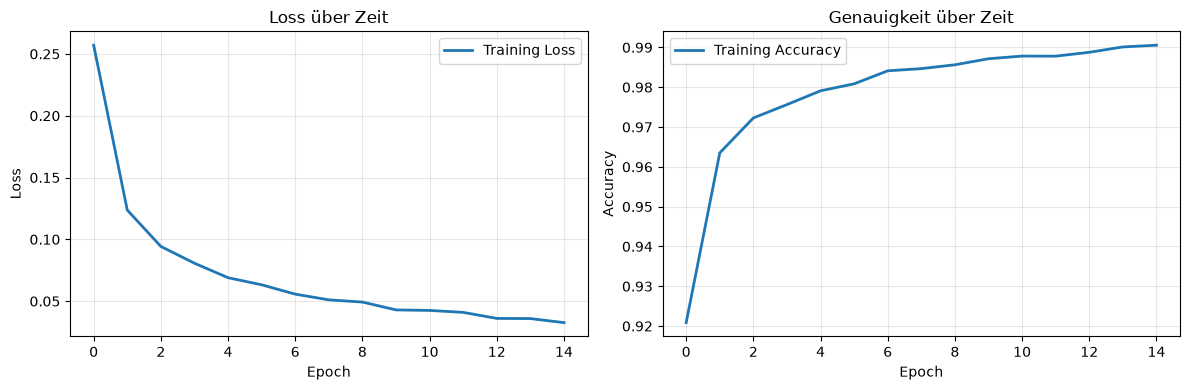

Finaler Training Loss: 0.0327
Finaler Training Accuracy: 0.9905


In [11]:
# Trainings-Verlauf plotten
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss-Plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
try: axes[0].plot(history.history['val_loss'], label='Validierung Loss', linewidth=2)
except: pass
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss über Zeit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy-Plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
try: axes[1].plot(history.history['val_accuracy'], label='Validierung Accuracy', linewidth=2)
except: pass
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Genauigkeit über Zeit')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Letzte Werte anzeigen
print(f"Finaler Training Loss: {history.history['loss'][-1]:.4f}")
try: print(f"Finaler Validierung Loss: {history.history['val_loss'][-1]:.4f}")
except: pass
print(f"Finaler Training Accuracy: {history.history['accuracy'][-1]:.4f}")
try: print(f"Finaler Validierung Accuracy: {history.history['val_accuracy'][-1]:.4f}")
except: pass

## 6. Auf Testset evaluieren

In [12]:
# Testset evaluieren
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_encoded, verbose=0)

print("\n" + "="*50)
print("TESTSET ERGEBNISSE")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*50)


TESTSET ERGEBNISSE
Test Loss: 0.0889
Test Accuracy: 0.9818 (98.18%)


## 7. Einzelne Vorhersagen testen

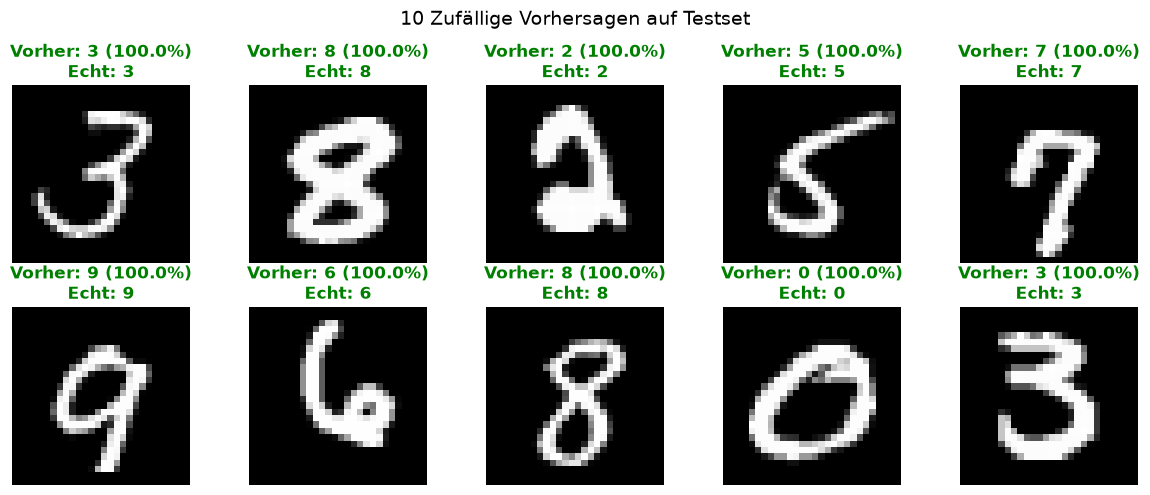

In [13]:
# 10 zufällige Test-Bilder vorhersagen
indices = np.random.choice(len(x_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, idx in enumerate(indices):
    # Vorhersage
    prediction = model.predict(x_test_flat[idx:idx+1], verbose=0)
    predicted_digit = np.argmax(prediction[0])
    confidence = prediction[0][predicted_digit]
    true_digit = y_test[idx]
    
    # Farbe basierend auf Richtig/Falsch
    color = 'green' if predicted_digit == true_digit else 'red'
    
    # Bild anzeigen
    ax = axes[i // 5, i % 5]
    ax.imshow(x_test[idx], cmap='gray')
    ax.set_title(f'Vorher: {predicted_digit} ({confidence:.1%})\nEcht: {true_digit}', 
                color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('10 Zufällige Vorhersagen auf Testset', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Modell speichern

In [14]:
# Modell speichern
model_path = 'mnist_model.h5'
model.save(model_path)
print(f"✓ Modell gespeichert: {model_path}")

# Später wieder laden und testen
loaded_model = keras.models.load_model(model_path)
loaded_test_acc = loaded_model.evaluate(x_test_flat, y_test_encoded, verbose=0)[1]
print(f"✓ Modell geladen und getestet: {loaded_test_acc:.4f} ({loaded_test_acc*100:.2f}%)")

✓ Modell gespeichert: mnist_model.h5


✓ Modell geladen und getestet: 0.9818 (98.18%)
